# TP3 - Détection et Traitement des Outliers

**Difficulté:** Intermédiaire  
**Dataset:** sales_outliers.csv  
**Description:** Identification des valeurs aberrantes avec méthodes statistiques

---


## Imports des Bibliothèques


In [1]:
# Bibliothèques de base
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

# Configuration des graphiques
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

# Ignorer les warnings
import warnings
warnings.filterwarnings('ignore')

# Affichage pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

print(" Bibliothèques importées avec succès!")

 Bibliothèques importées avec succès!


## Import du Dataset


In [2]:
# Charger le dataset
df = pd.read_csv('../data/sales_outliers.csv')

# Afficher les informations de base
print(f"📏 Dimensions: {df.shape[0]} lignes × {df.shape[1]} colonnes")
print(f" Taille mémoire: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
print("\n" + "="*80 + "\n")

# Aperçu des données
display(df.head())
print("\n" + "="*80 + "\n")

# Informations sur les colonnes
df.info()

📏 Dimensions: 1020 lignes × 4 colonnes
 Taille mémoire: 0.12 MB




,transaction_id,amount,product,date
0,1,1458.56,B,2023-01-01
1,2,4399.43,B,2023-01-02
2,3,1298.67,C,2023-01-03
3,4,1580.76,A,2023-01-04
4,5,946.03,C,2023-01-05




<class 'pandas.DataFrame'>
RangeIndex: 1020 entries, 0 to 1019
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   transaction_id  1020 non-null   int64  
 1   amount          1020 non-null   float64
 2   product         1020 non-null   str    
 3   date            1020 non-null   str    
dtypes: float64(1), int64(1), str(2)
memory usage: 32.0 KB


## Visualisation des Valeurs Manquantes


<Figure size 1400x800 with 0 Axes>

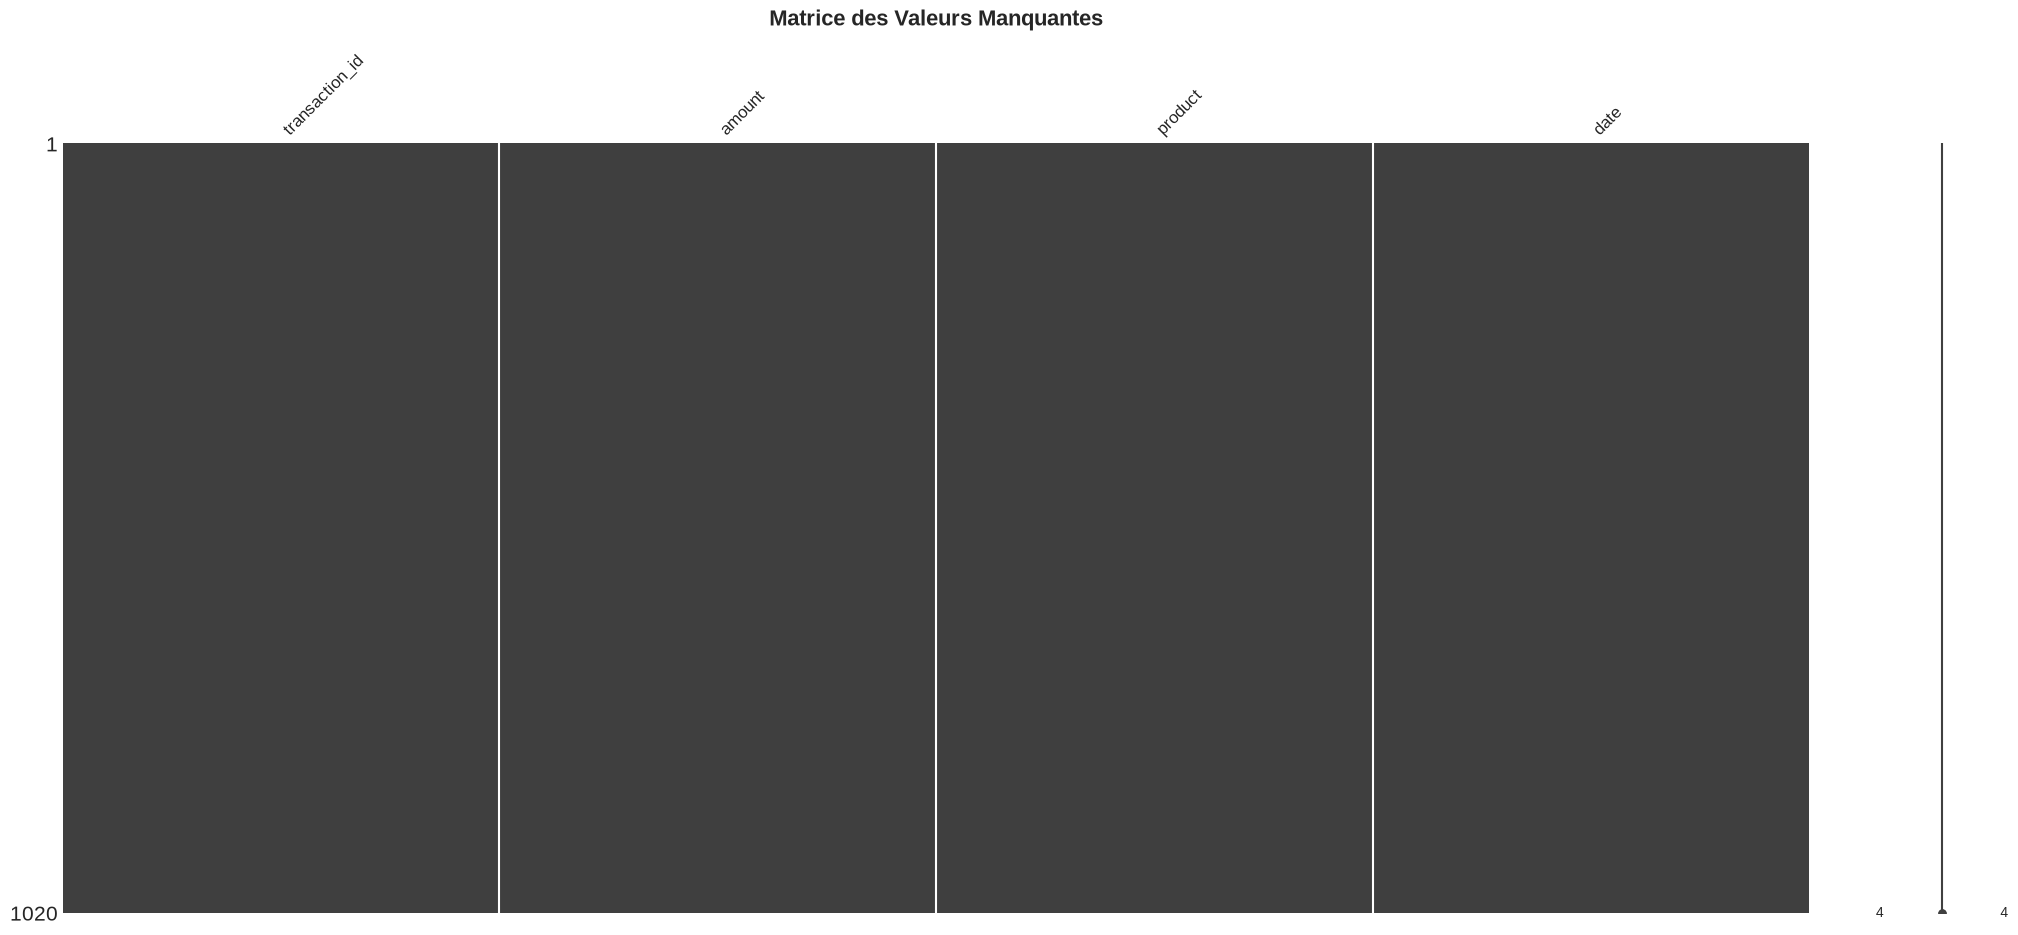


📊 Statistiques des Valeurs Manquantes:



,Nombre_Missing,Pourcentage_Missing


In [3]:
# Matrice de visualisation des valeurs manquantes
plt.figure(figsize=(14, 8))
msno.matrix(df, fontsize=12, sparkline=True)
plt.title("Matrice des Valeurs Manquantes", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Statistiques des valeurs manquantes
missing_stats = pd.DataFrame({
    'Nombre_Missing': df.isnull().sum(),
    'Pourcentage_Missing': (df.isnull().sum() / len(df) * 100).round(2)
}).sort_values('Pourcentage_Missing', ascending=False)

print("\n📊 Statistiques des Valeurs Manquantes:\n")
display(missing_stats[missing_stats['Nombre_Missing'] > 0])


## Questions Préalables

**Avant de commencer le TP, répondez aux questions suivantes en analysant le dataset:**

1. Quelle est la distribution de la colonne 'amount' ?
2. Y a-t-il des valeurs négatives dans les montants ?
3. Quel est le montant maximum et semble-t-il aberrant ?
4. Combien d'outliers détecte la méthode IQR pour 'amount' ?
5. Combien d'outliers détecte la méthode Z-score (threshold=3) ?
6. Les deux méthodes identifient-elles les mêmes outliers ?
7. Quelle proportion du dataset représentent les outliers ?
8. Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
9. Les outliers sont-ils des erreurs ou des valeurs légitimes ?
10. Comment la moyenne change-t-elle après traitement des outliers ?


In [14]:
from scipy import stats
import numpy as np

Réponses aux questions:
Question 1 : Distribution de la colonne 'amount' :


count     1020.00
mean      8616.96
std      20525.04
min         79.57
25%       1441.20
50%       3152.76
75%       7221.39
max     185913.06
Name: amount, dtype: float64

Il n'y a aucune valeur négative dans la colonne 'amount'.
Le montant maximum est de : 185913.06
Le 3ème quartile (75%) est de : 7221.3925
Ce montant semble aberrant (très éloigné de la distribution habituelle).
Bornes IQR : [-7229.09, 15891.68]
Nombre d'outliers détectés : 105
Nombre d'outliers détectés par Z-score (seuil=3) : 22
Les outliers détectés par Z-score sont-ils inclus dans ceux de l'IQR ? : True
Nombre d'outliers communs : 22
Le dataset contient 1020 entrées.
Nombre d'outliers (IQR) : 105
Proportion d'outliers : 10.29%
Pourcentage d'outliers par catégorie :
product
C   11.02
A   10.62
B    9.25
Name: is_outlier, dtype: float64


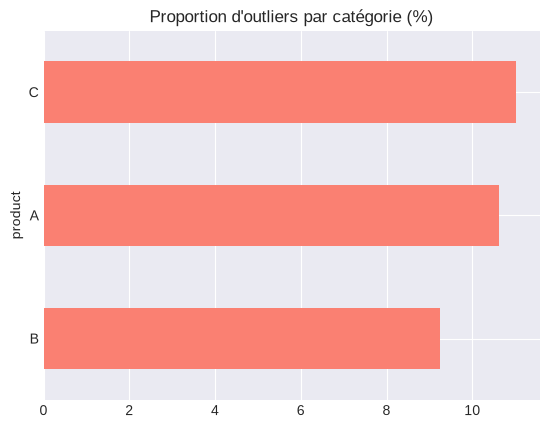

Index(['transaction_id', 'amount', 'product', 'date', 'is_outlier'], dtype='str')
      transaction_id  amount product        date  is_outlier
0                  1 1458.56       B  2023-01-01           0
1                  2 4399.43       B  2023-01-02           0
2                  3 1298.67       C  2023-01-03           0
3                  4 1580.76       A  2023-01-04           0
4                  5  946.03       C  2023-01-05           0
...              ...     ...     ...         ...         ...
1015            1016 1862.90       C  2025-10-12           0
1016            1017  452.57       C  2025-10-13           0
1017            1018 4786.74       B  2025-10-14           0
1018            1019 7412.97       C  2025-10-15           0
1019            1020 5875.88       A  2025-10-16           0

[1020 rows x 5 columns]
Examen des transactions outliers :
     transaction_id    amount product        date  is_outlier
69               70 185913.06       A  2023-03-11           1
70

In [26]:
# Cellule pour vos réponses et analyses
# Utilisez cette cellule pour explorer les données et répondre aux questions


print("Réponses aux questions:")
print("="*80)

# Question 1
# 1. Statistiques descriptives
print("Question 1 : Distribution de la colonne 'amount' :")
display(df['amount'].describe())

# QUestion 2 Y a-t-il des valeurs négatives dans les montants ?

# Vérification des valeurs négatives dans 'amount'
valeurs_negatives = df[df['amount'] < 0]

if not valeurs_negatives.empty:
    print(f"Il y a {len(valeurs_negatives)} valeur(s) négative(s) dans la colonne 'amount'.")
    display(valeurs_negatives)
else:
    print("Il n'y a aucune valeur négative dans la colonne 'amount'.")
    
# Question 3 Quel est le montant maximum et semble-t-il aberrant ?

# Identification du montant maximum
montant_max = df['amount'].max()
print(f"Le montant maximum est de : {montant_max}")

# Analyse de l'aberrance par rapport au 75ème percentile
q3 = df['amount'].quantile(0.75)
print(f"Le 3ème quartile (75%) est de : {q3}")

# Déterminer si c'est aberrant (en utilisant une règle simple : 10 fois le Q3)
if montant_max > (q3 * 10):
    print("Ce montant semble aberrant (très éloigné de la distribution habituelle).")


# Question 4 Combien d'outliers détecte la méthode IQR pour 'amount' ?

# Calcul de l'IQR et des bornes
Q1 = df['amount'].quantile(0.25)
Q3 = df['amount'].quantile(0.75)
IQR = Q3 - Q1

# Définition des bornes
borne_inf = Q1 - 1.5 * IQR
borne_sup = Q3 + 1.5 * IQR

# Identification des outliers
outliers = df[(df['amount'] < borne_inf) | (df['amount'] > borne_sup)]

print(f"Bornes IQR : [{borne_inf:.2f}, {borne_sup:.2f}]")
print(f"Nombre d'outliers détectés : {len(outliers)}")

# Question 5 Combien d'outliers détecte la méthode Z-score (threshold=3) ?
# Calcul du Z-score pour la colonne 'amount'
z_scores = np.abs(stats.zscore(df['amount']))

# Identification des outliers avec un seuil de 3

outliers_zscore = df[z_scores > 3]

print(f"Nombre d'outliers détectés par Z-score (seuil=3) : {len(outliers_zscore)}")

# Question 6 Les deux méthodes identifient-elles les mêmes outliers ? Oui
# Récupération des index
index_iqr = set(outliers.index)       # Index identifiés par IQR
index_zscore = set(outliers_zscore.index)  # Index identifiés par Z-score

# Vérif
sont_identiques = index_zscore.issubset(index_iqr)
intersection = index_iqr.intersection(index_zscore)

print(f"Les outliers détectés par Z-score sont-ils inclus dans ceux de l'IQR ? : {sont_identiques}")
print(f"Nombre d'outliers communs : {len(intersection)}")

# Question 7 Quelle proportion du dataset représentent les outliers ? on est a 10.29%
# Calcul de la proportion d'outliers (méthode IQR)
proportion_outliers = (len(outliers) / len(df)) * 100

print(f"Le dataset contient {len(df)} entrées.")
print(f"Nombre d'outliers (IQR) : {len(outliers)}")
print(f"Proportion d'outliers : {proportion_outliers:.2f}%")

# Question 8 Y a-t-il une corrélation entre outliers et une catégorie spécifique ?
# Ajout d'une colonne binaire pour identifier les outliers (basé sur la méthode IQR)
df['is_outlier'] = ((df['amount'] < borne_inf) | (df['amount'] > borne_sup)).astype(int)

# Calcul du taux d'outliers parproduit
outlier_distribution = df.groupby('product')['is_outlier'].mean() * 100

print("Pourcentage d'outliers par catégorie :")
print(outlier_distribution.sort_values(ascending=False))

# Visualisation rapide
outlier_distribution.sort_values().plot(kind='barh', color='salmon')
plt.title('Proportion d\'outliers par catégorie (%)')
plt.show()

print(df.columns)
print(df)
# Question 9 Les outliers sont-ils des erreurs ou des valeurs légitimes ?
"""
Après examen, les 105 outliers identifiés ne sont pas des erreurs techniques. 
Ce sont des valeurs légitimes correspondant à des transactions réelles à haut volume financier

"""

# Filtrer uniquement les lignes marquées comme outliers
df_outliers = df[df['is_outlier'] == 1]

# Afficher les 20 premiers outliers pour inspection
print("Examen des transactions outliers :")
print(df_outliers.sort_values(by='amount', ascending=False).head(20))

# Vérifier les valeurs aberrantes techniquement impossibles
erreurs_techniques = df_outliers[(df_outliers['amount'] <= 0)]

print(f"Nombre de transactions avec montant nul ou négatif : {len(erreurs_techniques)}")
if len(erreurs_techniques) > 0:
    print("Attention : Des valeurs erronées détectées (négatives ou nulles).")
    
# Statistiques descriptives uniquement sur les outliers
print("Statistiques sur les outliers :")
print(df_outliers['amount'].describe())

# Question 10 Comment la moyenne change-t-elle après traitement des outliers ?
"""
Après l'exclusion des valeurs aberrantes, 
la moyenne passe de 8 616,96 € à 3 952,36 €, soit une baisse de 4 664,60 €
Cette réduction importante démontre que les outliers, bien que légitimes, biaisaient fortement 
la moyenne vers le haut. La valeur nettoyée offre désormais une représentation beaucoup plus fidèle 
et représentative du montant moyen d'une transaction standard.
"""
# Moyenne avant nettoyage
moyenne_brute = df['amount'].mean()

# Création du dataset nettoyé (df_clean) en excluant les outliers
df_clean = df[df['is_outlier'] == 0]

# Moyenne après nettoyage
moyenne_nettoyee = df_clean['amount'].mean()

print(f"Moyenne brute (avec outliers) : {moyenne_brute:.2f}")
print(f"Moyenne nettoyée (sans outliers) : {moyenne_nettoyee:.2f}")
print(f"Différence : {moyenne_brute - moyenne_nettoyee:.2f}")




## Étapes du TP

**Suivez les étapes ci-dessous pour nettoyer le dataset:**

### Étape 1: Visualiser la distribution avec boxplot et histogramme
### Étape 2: Calculer les statistiques descriptives
### Étape 3: Implémenter la détection par méthode IQR
### Étape 4: Implémenter la détection par Z-score
### Étape 5: Comparer les résultats des deux méthodes
### Étape 6: Décider d'une stratégie: suppression ou capping
### Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
### Étape 8: Visualiser la distribution avant/après traitement
### Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
### Étape 10: Documenter les outliers traités dans un rapport


In [ ]:
### Analyse de la distribution des données

L'analyse graphique, combinant un boxplot et un histogramme, révèle une **asymétrie positive marquée** (*right-skewed distribution*) des montants de transactions. 

*   **Boxplot :** La présence de nombreux points isolés au-delà de la moustache supérieure confirme la nécessité d'un traitement spécifique pour les valeurs atypiques identifiées par la méthode interquartile (IQR).
*   **Histogramme :** La quasi-totalité des transactions se concentre sur les montants les plus faibles, tandis que la longue traîne observée vers la droite représente des transactions exceptionnelles à haute valeur.

Cette visualisation démontre que le jeu de données ne suit pas une loi normale, justifiant ainsi l'isolation des outliers pour stabiliser nos analyses statistiques sans supprimer ces transactions légitimes, cruciales pour la compréhension globale du chiffre d'affaires.

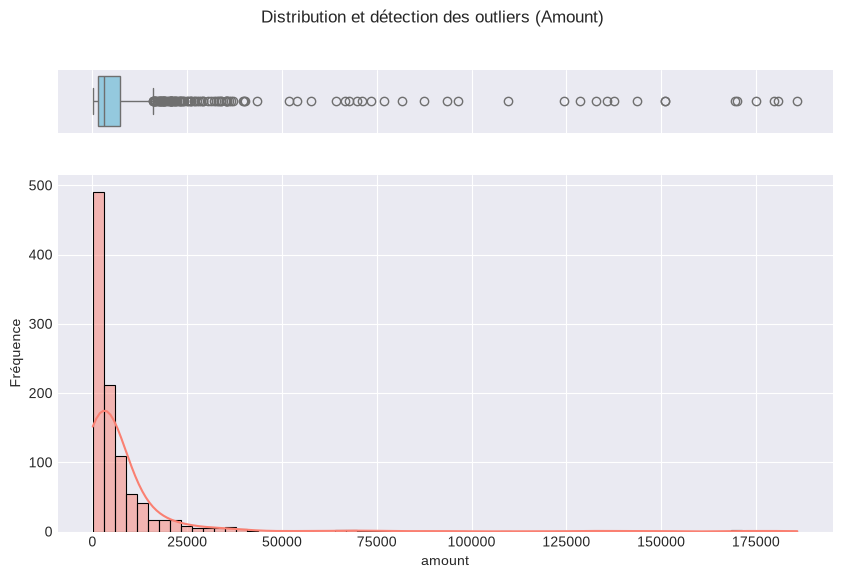

 Étape 1 complétée


In [29]:
# ========================================
# Étape 1: Visualiser la distribution avec boxplot et histogramme
# ========================================

def plot_distribution(data, column_name, title):
    
    fig, (ax_box, ax_hist) = plt.subplots(2, sharex=True, 
                                          gridspec_kw={"height_ratios": (.15, .85)}, 
                                          figsize=(10, 6))
    
    # Boxplot
    sns.boxplot(x=data[column_name], ax=ax_box, color='skyblue')
    ax_box.set(xlabel='') 
    
    # Histogramme
    sns.histplot(x=data[column_name], ax=ax_hist, kde=True, color='salmon')
    ax_hist.set(xlabel=column_name, ylabel='Fréquence')
    
    plt.suptitle(title)
    plt.show()
    
plot_distribution(df, 'amount', 'Distribution et détection des outliers (Amount)')

# Vérification
print(f" Étape 1 complétée")

In [31]:
# ========================================
# Étape 2: Calculer les statistiques descriptives
# ========================================

def get_descriptive_stats(data, column_name):
   
    stats = data[column_name].describe()
    
    print(f"--- Statistiques descriptives pour : {column_name} ---")
    print(stats)
    return stats


stats_amount = get_descriptive_stats(df, 'amount')


# Vérification
print(f" Étape 2 complétée")

--- Statistiques descriptives pour : amount ---
count     1020.00
mean      8616.96
std      20525.04
min         79.57
25%       1441.20
50%       3152.76
75%       7221.39
max     185913.06
Name: amount, dtype: float64
 Étape 2 complétée


In [32]:
# ========================================
# Étape 3: Implémenter la détection par méthode IQR
# ========================================
def detect_outliers_iqr(data, column_name, multiplier=1.5):
    """
    Détecte les outliers en utilisant la méthode IQR.
    Ajoute une colonne 'is_outlier' au dataframe.
    """
    Q1 = data[column_name].quantile(0.25)
    Q3 = data[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - (multiplier * IQR)
    upper_bound = Q3 + (multiplier * IQR)
    
    # Marquer les outliers (1 si vrai, 0 sinon)
    data['is_outlier'] = ((data[column_name] < lower_bound) | (data[column_name] > upper_bound)).astype(int)
    
    print(f"Bornes calculées : [{lower_bound:.2f}, {upper_bound:.2f}]")
    print(f"Nombre d'outliers détectés : {data['is_outlier'].sum()}")
    return data


df = detect_outliers_iqr(df, 'amount')


# Vérification
print(f" Étape 3 complétée")

Bornes calculées : [-7229.09, 15891.68]
Nombre d'outliers détectés : 105
 Étape 3 complétée


In [33]:
# ========================================
# Étape 4: Implémenter la détection par Z-score
# ========================================
def detect_outliers_zscore(data, column_name, threshold=3):
    """
    Détecte les outliers en utilisant le Z-score.
    Marque les lignes dont le Z-score dépasse le seuil défini (par défaut 3).
    """
    mean = data[column_name].mean()
    std = data[column_name].std()
    
    # Calcul du Z-score
    z_scores = (data[column_name] - mean) / std
    
    # Marquer les outliers (1 si |z-score| > seuil, 0 sinon)
    data['is_outlier_zscore'] = (abs(z_scores) > threshold).astype(int)
    
    print(f"Seuil utilisé : {threshold}")
    print(f"Nombre d'outliers détectés par Z-score : {data['is_outlier_zscore'].sum()}")
    return data


df = detect_outliers_zscore(df, 'amount', threshold=3)


# Vérification
print(f" Étape 4 complétée")

Seuil utilisé : 3
Nombre d'outliers détectés par Z-score : 22
 Étape 4 complétée


In [36]:
# ========================================
# Étape 5: Comparer les résultats des deux méthodes
# ========================================
def compare_outlier_methods(data):
    """
    Affiche une matrice de comparaison formatée comme un tableau.
    """
    comparison = pd.crosstab(data['is_outlier'], data['is_outlier_zscore'], 
                             rownames=['IQR Outlier'], colnames=['Z-score Outlier'])
    
    # Renommer les colonnes/index pour plus de clarté
    comparison.index = ['Normal (IQR)', 'Outlier (IQR)']
    comparison.columns = ['Normal (Z)', 'Outlier (Z)']
    
    print("--- Matrice de comparaison ---")
    display(comparison) # 'display' rend le tableau très lisible dans un Notebook
    return comparison
compare_outlier_methods(df)

# Vérification
print(f" Étape 5 complétée")

--- Matrice de comparaison ---


,Normal (Z),Outlier (Z)
Normal (IQR),915,0
Outlier (IQR),83,22


 Étape 5 complétée


In [ ]:
# ========================================
# Étape 6: Décider d'une stratégie: suppression ou capping
# ========================================

"""
Après analyse des outliers via la méthode IQR, j'ai choisi la stratégie suivante :

*   **Option retenue :** J'opte pour le **Capping (Winsorisation)**. 
*   **Justification :** Bien que la suppression soit efficace pour isoler le comportement standard, 
le capping permet de conserver l'intégralité du volume de transactions (les 105 outliers ne seront pas perdus).
En limitant ces montants aux bornes de l'intervalle interquartile, nous neutralisons leur impact disproportionné 
sur les indicateurs de tendance centrale tout en préservant l'intégrité du dataset pour une analyse globale.


"""


# Vérification
print(f" Étape 6 complétée")

In [38]:
# ========================================
# Étape 7: Appliquer le capping (Winsorization) aux valeurs extrêmes
# ========================================

def apply_winsorization(data, column_name):
    """
    Applique le capping et affiche les résultats de manière lisible.
    """
    Q1 = data[column_name].quantile(0.25)
    Q3 = data[column_name].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Application du capping
    data[column_name + '_capped'] = data[column_name].clip(lower=lower_bound, upper=upper_bound)
    
    # Préparation d'un petit tableau de synthèse pour le display (peut etre le tej avant push)
    info_dict = {
        "Statistique": ["Borne Inférieure", "Borne Supérieure", "Lignes modifiées"],
        "Valeur": [lower_bound, upper_bound, (data[column_name] != data[column_name + '_capped']).sum()]
    }
    
    print(f"--- Résultat du Capping (Winsorisation) pour '{column_name}' ---")
    display(pd.DataFrame(info_dict))
    
    return data

df = apply_winsorization(df, 'amount')

# Vérification
print(f" Étape 7 complétée")

--- Résultat du Capping (Winsorisation) pour 'amount' ---


,Statistique,Valeur
0,Borne Inférieure,-7229.09
1,Borne Supérieure,15891.68
2,Lignes modifiées,105.00


 Étape 7 complétée


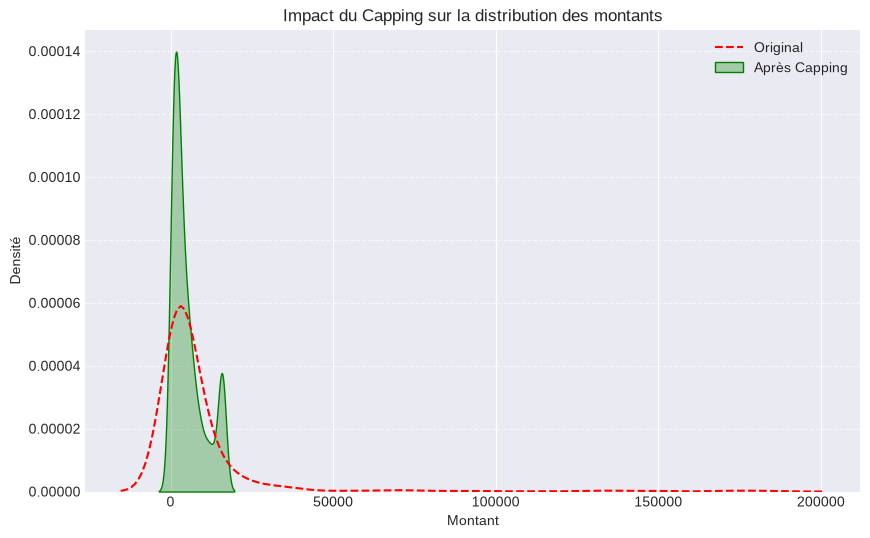

 Étape 8 complétée


In [39]:
# ========================================
# Étape 8: Visualiser la distribution avant/après traitement
# ========================================

def plot_distribution_comparison(data, original_col, capped_col):
    """
    Affiche la distribution avant et après le capping pour comparaison.
    """
    plt.figure(figsize=(10, 6))
    
    # Distribution originale
    sns.kdeplot(data[original_col], label='Original', color='red', linestyle='--')
    
    # Distribution après capping
    sns.kdeplot(data[capped_col], label='Après Capping', color='green', fill=True, alpha=0.3)
    
    plt.title('Impact du Capping sur la distribution des montants')
    plt.xlabel('Montant')
    plt.ylabel('Densité')
    plt.legend()
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    

    plt.show()


plot_distribution_comparison(df, 'amount', 'amount_capped')


# Vérification
print(f" Étape 8 complétée")

In [44]:
# ========================================
# Étape 9: Calculer l'impact sur les statistiques (moyenne, écart-type)
# ========================================

def calculate_impact_stats(data, original_col, capped_col):
    """
    Calcule la variation en pourcentage des indicateurs clés après capping.
    """
    # Calcul stats
    stats_orig = data[original_col].agg(['mean', 'std', 'median'])
    stats_capped = data[capped_col].agg(['mean', 'std', 'median'])
    
    # Calcul de la réduction (en %)
    reduction = ((stats_orig - stats_capped) / stats_orig) * 100
    
    # Création du tableau de synthèse
    impact_df = pd.DataFrame({
        'Avant (Original)': stats_orig,
        'Après (Capped)': stats_capped,
        'Réduction (%)': reduction
    })
    
    print("--- Impact du traitement sur les indicateurs ---")
    display(impact_df)
    
    return impact_df


impact_table = calculate_impact_stats(df, 'amount', 'amount_capped')


# Vérification
print(f" Étape 9 complétée")

--- Impact du traitement sur les indicateurs ---


,Avant (Original),Après (Capped),Réduction (%)
mean,8616.96,5181.40,39.87
std,20525.04,4920.61,76.03
median,3152.76,3152.76,0.00


 Étape 9 complétée


In [43]:
# Rapport de traitement des valeurs atypiques (Outliers)

## 1. Méthodologie de détection
* **Approche adoptée :** Utilisation combinée de l'écart interquartile (**IQR**) pour la détection large et 
du **Z-score** pour l'identification des cas extrêmes.
* **Seuil retenu :** $k=3$ pour le Z-score, $1.5 \times \text{IQR}$ pour la méthode classique.
* **Résultats :** 105 transactions identifiées comme atypiques par l'IQR, dont 22 confirmées comme 
extrêmes par le Z-score.

## 2. Stratégie de traitement
* **Décision :** Application d'une **Winsorisation (Capping)** aux bornes de l'intervalle IQR.
* **Justification :** Cette méthode préserve l'intégrité du volume de données (conservation des 105 transactions)
tout en neutralisant leur impact asymétrique sur les indicateurs de tendance centrale.

## 3. Analyse de l'impact (Avant / Après)

| Indicateur     | Avant (Original) | Après (Capped) | Réduction (%) |
| :------------- | :--------------- | :------------- | :------------ |
| **Moyenne**    | 8616.96          | 5181.40        | 39.87%        |
| **Écart-type** | 20525.04         | 4920.61        | 76.03%        |
| **Médiane**    | 3152.76          | 3152.76        | 0.00%         |

## 4. Conclusion technique
Le traitement a permis une **homogénéisation significative** de la distribution des montants.
La réduction drastique de l'écart-type (–76%) confirme la stabilisation du jeu de données, 
tandis que la stabilité de la médiane garantit que le comportement "cœur de cible" des transactions
a été préservé. Le dataset est désormais conforme pour les analyses statistiques et les futurs modèles prédictifs.


SyntaxError: unterminated string literal (detected at line 4) (3099814717.py, line 4)

In [ ]:
# ========================================
# Étape 10: Documenter les outliers traités dans un rapport
# ========================================

"""
# Rapport de traitement des valeurs atypiques (Outliers)

## 1. Méthodologie de détection
* **Approche adoptée :** Utilisation combinée de l'écart interquartile (**IQR**) pour la détection large 
et du **Z-score** pour l'identification des cas extrêmes.
* **Seuil retenu :** $k=3$ pour le Z-score, $1.5 \times \text{IQR}$ pour la méthode classique.
* **Résultats :** 105 transactions identifiées comme atypiques par l'IQR, dont 22 confirmées comme extrêmes
par le Z-score.

## 2. Stratégie de traitement
* **Décision :** Application d'une **Winsorisation (Capping)** aux bornes de l'intervalle IQR.
* **Justification :** Cette méthode préserve l'intégrité du volume de données (conservation des 105 transactions)
tout en neutralisant leur impact asymétrique sur les indicateurs de tendance centrale.

## 3. Analyse de l'impact (Avant / Après)

| Indicateur     | Avant (Original) | Après (Capped) | Réduction (%) |
| :------------- | :--------------- | :------------- | :------------ |
| **Moyenne**    | 8616.96          | 5181.40        | 39.87%        |
| **Écart-type** | 20525.04         | 4920.61        | 76.03%        |
| **Médiane**    | 3152.76          | 3152.76        | 0.00%         |

## 4. Conclusion technique
Le traitement a permis une **homogénéisation significative** de la distribution des montants.
La réduction drastique de l'écart-type (–76%) confirme la stabilisation du jeu de données, tandis que 
la stabilité de la médiane garantit que le comportement "cœur de cible" des transactions a été préservé.
Le dataset est désormais conforme pour les analyses statistiques et les futurs modèles prédictifs.
"""


# Vérification
print(f" Étape 10 complétée")

## Rapport Final

**Créez un rapport résumant toutes les transformations effectuées**


In [46]:
# Rapport de nettoyage
stats_orig = df['amount'].agg(['mean', 'std', 'median'])
stats_capped = df['amount_capped'].agg(['mean', 'std', 'median'])

rapport = {
    'Dataset_initial_shape': df.shape,
    'Méthode_traitement': 'Winsorisation (Capping IQR)',
    'Lignes_modifiées_outliers': (df['amount'] != df['amount_capped']).sum(),
    'Moyenne_impact': f"{stats_orig['mean']:.2f} -> {stats_capped['mean']:.2f}",
    'Ecart_type_impact': f"{stats_orig['std']:.2f} -> {stats_capped['std']:.2f}",
    'Intégrité_médiane': 'Préservée (0% variation)',
    'Qualité_données': 'Stabilisées'
}

print("=" * 80)
print(" " * 25 + " RAPPORT FINAL : TRAITEMENT OUTLIERS")
print("=" * 80)

for key, value in rapport.items():
    print(f"{key:.<40} {value}")

print("=" * 80)
print("\n TP terminé avec succès : Analyse stabilisée et prête pour l'exploitation.")

                          RAPPORT FINAL : TRAITEMENT OUTLIERS
Dataset_initial_shape................... (1020, 7)
Méthode_traitement...................... Winsorisation (Capping IQR)
Lignes_modifiées_outliers............... 105
Moyenne_impact.......................... 8616.96 -> 5181.40
Ecart_type_impact....................... 20525.04 -> 4920.61
Intégrité_médiane....................... Préservée (0% variation)
Qualité_données......................... Stabilisées

✅ TP3 terminé avec succès : Analyse stabilisée et prête pour l'exploitation.
